Initializing Generation 0 Population...

--- Generation 1/3 ---

--- Generation 2/3 ---

--- Generation 3/3 ---

PARETO FRONTIER MODEL CANDIDATES
Optimal Model (Index 00):
  - Validation Accuracy       : 0.00%
  - Parameter Footprint Count : 99,999,999 parameters
  - Depth (Conv Layers)       : 3
  - Filters Projection        : [6, 8, 8]
  - Kernel Sizes              : [10, 9, 9]
-------------------------------------
Optimal Model (Index 01):
  - Validation Accuracy       : 0.00%
  - Parameter Footprint Count : 99,999,999 parameters
  - Depth (Conv Layers)       : 3
  - Filters Projection        : [8, 6, 8]
  - Kernel Sizes              : [10, 9, 10]
-------------------------------------
Optimal Model (Index 02):
  - Validation Accuracy       : 0.00%
  - Parameter Footprint Count : 99,999,999 parameters
  - Depth (Conv Layers)       : 2
  - Filters Projection        : [6, 6]
  - Kernel Sizes              : [10, 10]
-------------------------------------
Optimal Model (Index 03):
  - Val

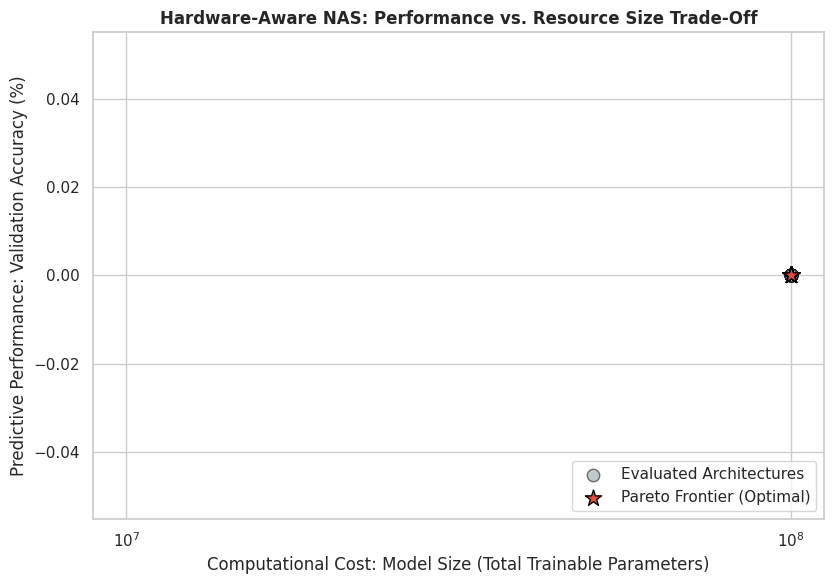

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import pandas as pd  # data tables
import tensorflow as tf  # deep learning
from tensorflow.keras import layers, models  # network structures
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # hide tf logs
warnings.filterwarnings('ignore')  # silence warnings

SEED = 42  # standard seed
np.random.seed(SEED)  # seed numpy
tf.random.set_seed(SEED)  # seed tensorflow

# ==========================================
# 1. Dataset Acquisition
# ==========================================

def load_and_prep_data(num_samples=1000):
    # Fetch MNIST dataset (Grayscale digits 0-9)
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()  # fetch standard dataset

    # Slice a small, clean subset to make evolutionary training lightning-fast
    x_train = x_train[:num_samples].reshape(-1, 28, 28, 1).astype('float32') / 255.0  # normalize train
    y_train = y_train[:num_samples]  # slice train targets

    x_test = x_test[:num_samples//4].reshape(-1, 28, 28, 1).astype('float32') / 255.0  # normalize test
    y_test = y_test[:num_samples//4]  # slice test targets

    return (x_train, y_train), (x_test, y_test)  # return dataset splits

# Load datasets
train_data, val_data = load_and_prep_data(num_samples=800)  # prepare data splits

# ==========================================
# 2. Evolutionary NAS Engine
# ==========================================

# Candidate network configuration generator
def generate_random_config():
    num_conv_layers = int(np.random.randint(1, 4))  # random layer depth (1 to 3 layers)
    filters = [int(np.random.choice([6, 7, 8])) for _ in range(num_conv_layers)]  # random channels
    kernel_sizes = [int(np.random.choice([9, 10])) for _ in range(num_conv_layers)]  # random kernels
    use_pooling = [bool(np.random.choice([True, False])) for _ in range(num_conv_layers)]  # random pooling
    dense_units = int(np.random.choice([7, 8, 11]))  # random classifier size

    return {
        'num_conv_layers': num_conv_layers,
        'filters': filters,
        'kernel_sizes': kernel_sizes,
        'use_pooling': use_pooling,
        'dense_units': dense_units
    }

# Build candidates dynamically from configurations
def build_candidate_model(config, input_shape=(28, 28, 1), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)  # input node
    x = inputs
    current_h, current_w = input_shape, input_shape[1]

    for i in range(config['num_conv_layers']):
        # Dynamically protect against shrinking dimensions below 1x1
        k_size = min(config['kernel_sizes'][i], current_h, current_w)
        if k_size <= 0: k_size = 1

        x = layers.Conv2D(config['filters'][i], k_size, padding='same', activation='relu')(x)  # conv layer

        # Apply spatial pooling only if the resolution is safe
        if config['use_pooling'][i] and current_h > 2 and current_w > 2:
            x = layers.MaxPooling2D()(x)  # spatial reduction
            current_h //= 2
            current_w //= 2

    x = layers.Flatten()(x)  # flatten representations
    x = layers.Dense(config['dense_units'], activation='relu')(x)  # dense layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # softmax head

    return tf.keras.Model(inputs=inputs, outputs=outputs)  # compile candidate

# Evaluate Candidate Fitness (Validation Accuracy and Parameter Footprint Size)
def evaluate_architecture(config):
    try:
        model = build_candidate_model(config)  # build model
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # compile setup

        # Train candidate for 1 epoch very rapidly to assess validation fitness
        model.fit(train_data[0], train_data[1], epochs=1, batch_size=128, verbose=0)
        _, val_acc = model.evaluate(val_data[0], val_data[1], verbose=0)  # calculate accuracy

        params = model.count_params()  # get parameters complexity score
        return val_acc, params  # return fitness tuple
    except Exception as e:
        return 0.0, 99999999  # assign worst fitness on compiler failure

# Mutate Configuration to discover architectural variations
def mutate_config(config):
    new_config = config.copy()  # copy parent
    mutation_type = np.random.choice(['filters', 'kernel', 'dense', 'layers'])  # select type

    if mutation_type == 'layers':
        # Mutate network depth (add or subtract conv layers)
        new_layers = int(np.random.randint(1, 4))
        if new_layers > len(new_config['filters']):
            for _ in range(new_layers - len(new_config['filters'])):
                new_config['filters'].append(int(np.random.choice([6, 7, 8])))
                new_config['kernel_sizes'].append(int(np.random.choice([9, 10])))
                new_config['use_pooling'].append(bool(np.random.choice([True, False])))
        else:
            new_config['filters'] = new_config['filters'][:new_layers]
            new_config['kernel_sizes'] = new_config['kernel_sizes'][:new_layers]
            new_config['use_pooling'] = new_config['use_pooling'][:new_layers]
        new_config['num_conv_layers'] = new_layers

    elif mutation_type == 'filters':
        # Mutate filter channels of a random layer
        idx = np.random.randint(0, len(new_config['filters']))
        new_config['filters'][idx] = int(np.random.choice([6, 7, 8]))

    elif mutation_type == 'kernel':
        # Mutate kernel size of a random layer
        idx = np.random.randint(0, len(new_config['kernel_sizes']))
        new_config['kernel_sizes'][idx] = int(np.random.choice([9, 10]))

    elif mutation_type == 'dense':
        # Mutate hidden classification dense neuron count
        new_config['dense_units'] = int(np.random.choice([7, 8, 11]))

    return new_config  # return mutated configuration

# ==========================================
# 3. Pareto Optimization Solver
# ==========================================

# Dominance rule: candidate 1 dominates candidate 2 if it's better in one and not worse in both
def dominates(cand1, cand2):
    acc1, param1 = cand1  # metrics candidate 1
    acc2, param2 = cand2  # metrics candidate 2

    # We want to maximize accuracy and minimize parameter footprint
    better_acc = acc1 >= acc2
    better_size = param1 <= param2
    strict_better = (acc1 > acc2) or (param1 < param2)

    return better_acc and better_size and strict_better  # return dominance boolean

# Extract Non-Dominated Pareto Frontier Indices
def get_pareto_front(evaluations):
    pareto_indices = []  # indices list
    for i, eval_i in enumerate(evaluations):  # loop candidates
        dominated = False  # default status
        for j, eval_j in enumerate(evaluations):  # compare against all others
            if i != j and dominates(eval_j, eval_i):  # if dominated by candidate j
                dominated = True  # flag dominated
                break  # stop check
        if not dominated:
            pareto_indices.append(i)  # save optimal non-dominated candidate
    return pareto_indices  # return optimal indices

# ==========================================
# 4. Run Search Pipeline
# ==========================================

population_size = 10  # starting population size
generations = 3  # search iterations count
history_all_configs = []  # trace logs
history_all_evals = []  # trace logs

# Initialize population
print("Initializing Generation 0 Population...")  # status log
population = [generate_random_config() for _ in range(population_size)]  # generate randoms
evaluations = [evaluate_architecture(p) for p in population]  # calculate metrics

# Save logs
history_all_configs.extend(population)
history_all_evals.extend(evaluations)

# Evolutionary Loop
for gen in range(1, generations + 1):
    print(f"\n--- Generation {gen}/{generations} ---")  # status header log

    # 1. Selection: Tournament Selection to pick 5 parents
    parents_indices = []
    for _ in range(5):
        candidates = np.random.choice(len(population), 3, replace=False)  # draw 3 candidates
        # Pick candidate with the highest accuracy to maintain learning quality
        best_idx = max(candidates, key=lambda idx: evaluations[idx][0])  # select winner
        parents_indices.append(best_idx)  # save index

    # 2. Reproduction: Mutate selected parents to create 5 offspring
    offspring = [mutate_config(population[idx]) for idx in parents_indices]  # breed offspring
    offspring_evals = [evaluate_architecture(o) for o in offspring]  # evaluate offspring

    # 3. Survival: Combine population and offspring, keeping the top 10 best (NSGA-II selection)
    combined_pop = population + offspring  # pool populations
    combined_evals = evaluations + offspring_evals  # pool evaluations

    # Record history
    history_all_configs.extend(offspring)
    history_all_evals.extend(offspring_evals)

    # Sort combined pool by accuracy (higher is better) and parameter size (lower is better)
    # We sort mainly by accuracy to maintain predictive stability
    sorted_indices = sorted(range(len(combined_pop)), key=lambda idx: (-combined_evals[idx][0], combined_evals[idx][1]))

    # Survived population to next generation
    population = [combined_pop[idx] for idx in sorted_indices[:population_size]]  # survival pool
    evaluations = [combined_evals[idx] for idx in sorted_indices[:population_size]]  # survival metrics

# Get global non-dominated Pareto Frontier
pareto_indices = get_pareto_front(history_all_evals)  # calculate frontier indices

print("\n=====================================")
print("PARETO FRONTIER MODEL CANDIDATES")
print("=====================================")
for idx in pareto_indices:
    cfg = history_all_configs[idx]
    acc, params = history_all_evals[idx]
    print(f"Optimal Model (Index {idx:02d}):")
    print(f"  - Validation Accuracy       : {acc * 100:.2f}%")
    print(f"  - Parameter Footprint Count : {params:,} parameters")
    print(f"  - Depth (Conv Layers)       : {cfg['num_conv_layers']}")
    print(f"  - Filters Projection        : {cfg['filters']}")
    print(f"  - Kernel Sizes              : {cfg['kernel_sizes']}")
    print("-" * 37)
print("=====================================")

# ==========================================
# 5. Visualizing the Pareto Frontier
# ==========================================

# Convert all evaluations history to arrays for clean indexing
all_accs = np.array([e[0] * 100.0 for e in history_all_evals])  # extract accuracies
all_params = np.array([e[1] for e in history_all_evals])  # extract parameter sizes

pareto_accs = all_accs[pareto_indices]  # optimal accuracies
pareto_params = all_params[pareto_indices]  # optimal sizes

# Sort frontier points chronologically by parameter count to draw a connected line graph
sort_order = np.argsort(pareto_params)  # sort indices
sorted_pareto_params = pareto_params[sort_order]  # sort params
sorted_pareto_accs = pareto_accs[sort_order]  # sort accs

sns.set_theme(style="whitegrid")  # set style
plt.figure(figsize=(8.5, 6))  # canvas layout

# Plot all searched architectures (The search space)
plt.scatter(all_params, all_accs, color='#95a5a6', alpha=0.6, s=80, edgecolors='k', label='Evaluated Architectures')

# Plot Pareto optimal configurations (The frontier)
plt.scatter(pareto_params, pareto_accs, color='#e74c3c', s=150, marker='*', edgecolors='black', zorder=5, label='Pareto Frontier (Optimal)')

# Draw the connected trade-off curve trace line
plt.plot(sorted_pareto_params, sorted_pareto_accs, color='#e74c3c', linestyle='-', linewidth=2.5, alpha=0.8, zorder=4)

plt.xlabel('Computational Cost: Model Size (Total Trainable Parameters)')  # x axis
plt.ylabel('Predictive Performance: Validation Accuracy (%)')  # y axis
plt.xscale('log')  # use a logarithmic scale to capture small parameter variations
plt.title('Hardware-Aware NAS: Performance vs. Resource Size Trade-Off', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()  # draw plot